In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:

df = pd.read_csv('deliriumwatch_master_V5.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

Shape: (25843, 28)

Columns: ['subject_id', 'stay_id', 'delirium_label', 'age', 'gender', 'first_careunit', 'window_hours', 'avg_sofa', 'max_sofa', 'admission_sofa', 'hr_mean', 'hr_std', 'hr_min', 'hr_max', 'rr_mean', 'rr_std', 'spo2_mean', 'spo2_min', 'nibp_mean', 'nibp_min', 'abp_mean', 'propofol_total', 'midazolam_total', 'lorazepam_total', 'fentanyl_total', 'unique_sedation_drugs', 'nid_score', 'abp_measured']

Data types:
 subject_id                 int64
stay_id                    int64
delirium_label             int64
age                        int64
gender                       str
first_careunit               str
window_hours               int64
avg_sofa                 float64
max_sofa                   int64
admission_sofa             int64
hr_mean                  float64
hr_std                   float64
hr_min                   float64
hr_max                   float64
rr_mean                  float64
rr_std                   float64
spo2_mean                float64
spo2_mi

In [3]:

cols = [
    'subject_id',     
    'stay_id',
    'window_hours',
]

df_clean = df.drop(columns=cols)
print("Shape", df_clean.shape)
print("Remaining columns:", df_clean.columns.tolist())

Shape (25843, 25)
Remaining columns: ['delirium_label', 'age', 'gender', 'first_careunit', 'avg_sofa', 'max_sofa', 'admission_sofa', 'hr_mean', 'hr_std', 'hr_min', 'hr_max', 'rr_mean', 'rr_std', 'spo2_mean', 'spo2_min', 'nibp_mean', 'nibp_min', 'abp_mean', 'propofol_total', 'midazolam_total', 'lorazepam_total', 'fentanyl_total', 'unique_sedation_drugs', 'nid_score', 'abp_measured']


In [4]:
# Missing value analysis
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

#shows columns that are missing
print(missing_df[missing_df['missing_count'] > 0])

           missing_count  missing_pct
abp_mean           14245    55.121309
nibp_mean           1589     6.148667
nibp_min            1589     6.148667
rr_std                35     0.135433
rr_mean               23     0.088999
spo2_min               2     0.007739
spo2_mean              2     0.007739
hr_std                 2     0.007739


In [5]:
# creates a flag BEFORE filling
df_clean['abp_measured'] = (
    df_clean['abp_mean'].notnull().astype(int)
)

# Fill abp_mean with 0 (no arterial line = 0 reading)
df_clean['abp_mean'] = df_clean['abp_mean'].fillna(0)

# missing values: filled with median
median_cols = [
    'nibp_mean', 'nibp_min', 
    'rr_std', 'rr_mean',
    'spo2_mean', 'spo2_min', 
    'hr_std'
]
for col in median_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"{col}: filled with median {median_val:.2f}")
print("\nMissing after treatment:", 
      df_clean.isnull().sum().sum())

nibp_mean: filled with median 77.75
nibp_min: filled with median 59.00
rr_std: filled with median 3.96
rr_mean: filled with median 19.14
spo2_mean: filled with median 96.80
spo2_min: filled with median 91.00
hr_std: filled with median 9.19

Missing after treatment: 0


Class distribution:
No delirium (0): 14028 (54.3%)
Delirium    (1): 11815 (45.7%)
Ratio: 1:1.2


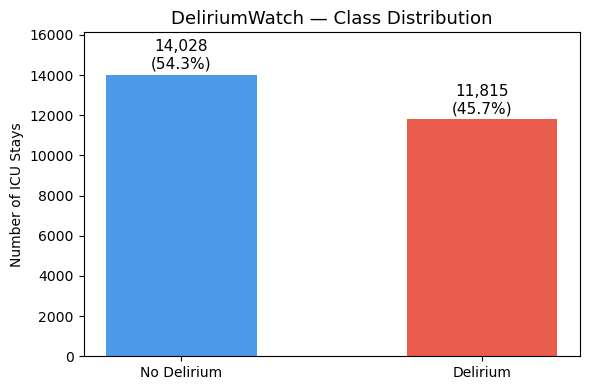

In [6]:
counts = df_clean['delirium_label'].value_counts()
pcts = df_clean['delirium_label'].value_counts(
    normalize=True
) * 100

print("Class distribution:")
print(f"No delirium (0): {counts[0]} ({pcts[0]:.1f}%)")
print(f"Delirium    (1): {counts[1]} ({pcts[1]:.1f}%)")
print(f"Ratio: 1:{counts[0]/counts[1]:.1f}")


fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Delirium', 'Delirium'], 
               counts.values,
               color=['#4C9BE8', '#E85D4C'],
               width=0.5)

# Adds count
for bar, count, pct in zip(
    bars, counts.values, pcts.values
):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 300,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', fontsize=11)

ax.set_title('DeliriumWatch — Class Distribution', 
             fontsize=13)
ax.set_ylabel('Number of ICU Stays')
ax.set_ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()

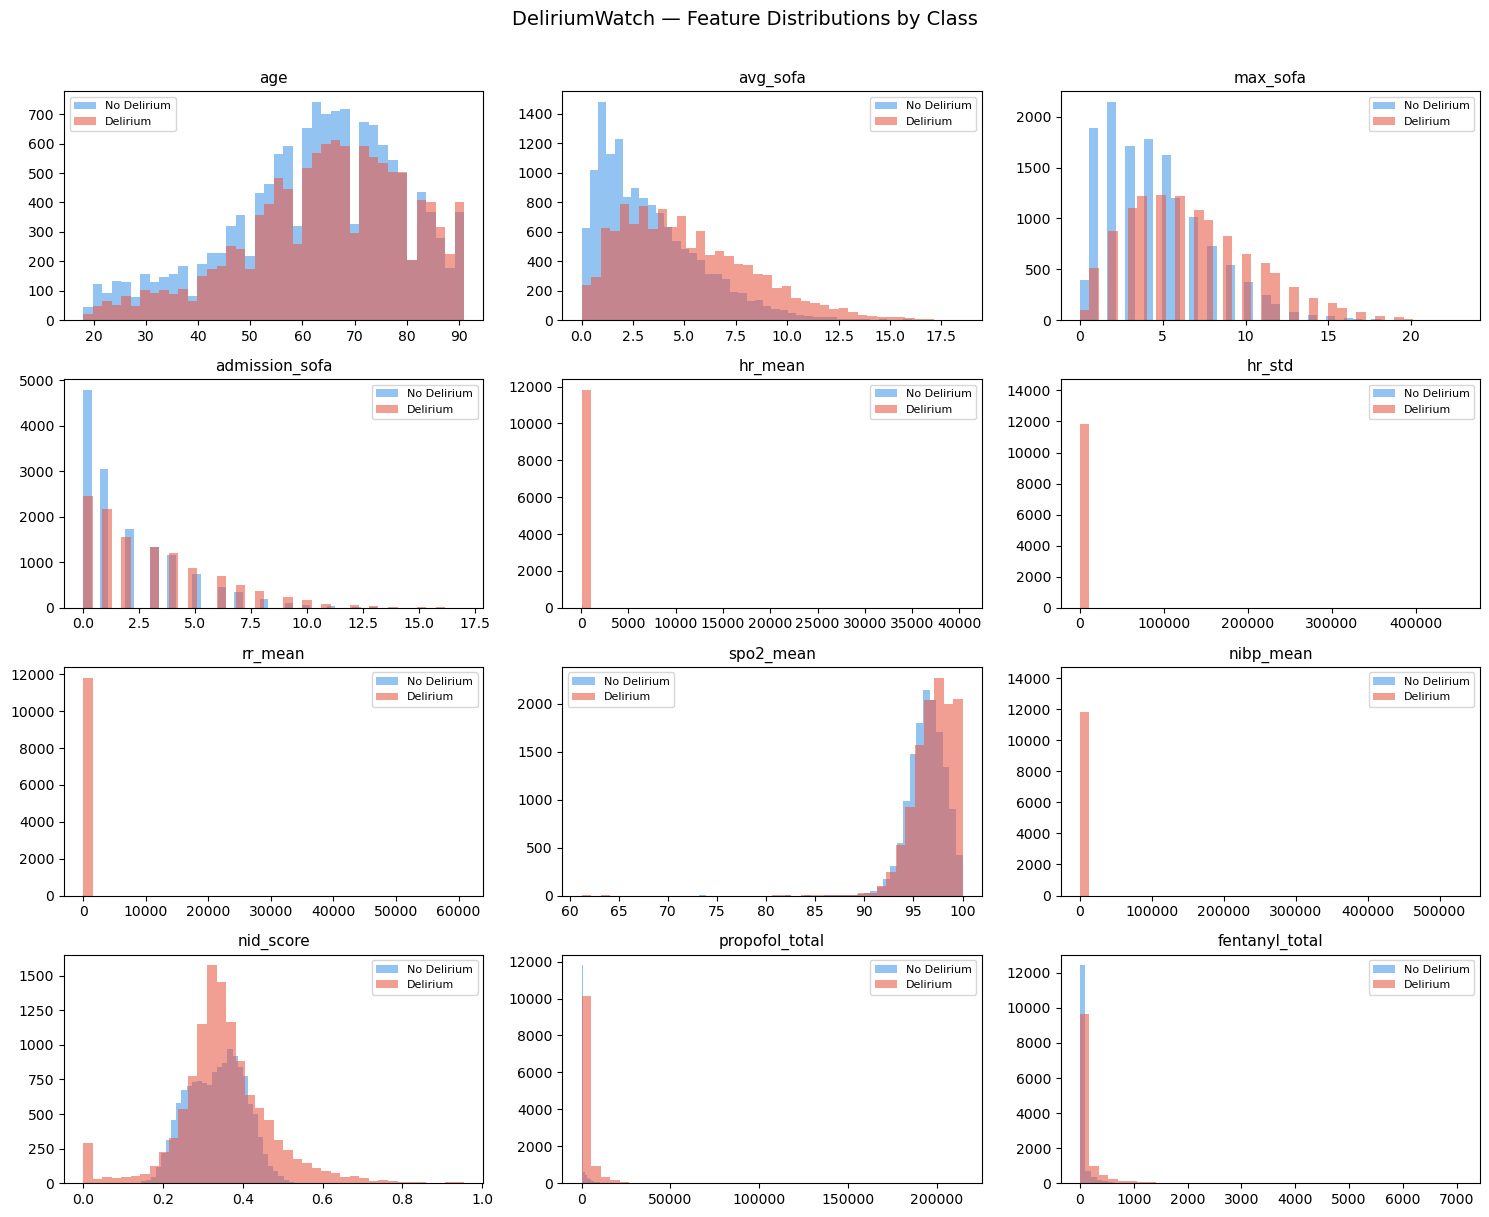

In [7]:
numerical_cols = [
    'age', 'avg_sofa', 'max_sofa', 
    'admission_sofa', 'hr_mean', 'hr_std',
    'rr_mean', 'spo2_mean', 'nibp_mean', 
    'nid_score', 'propofol_total', 
    'fentanyl_total'
]

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(
        df_clean[df_clean['delirium_label']==0][col], 
        bins=40, alpha=0.6, 
        color='#4C9BE8', label='No Delirium'
    )
    axes[i].hist(
        df_clean[df_clean['delirium_label']==1][col], 
        bins=40, alpha=0.6, 
        color='#E85D4C', label='Delirium'
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle(
    'DeliriumWatch — Feature Distributions by Class', 
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

In [8]:
# outlier scale
outlier_cols = [
    'hr_mean', 'hr_std', 'hr_min', 'hr_max',
    'rr_mean', 'rr_std', 'spo2_mean', 'spo2_min',
    'nibp_mean', 'nibp_min', 'propofol_total',
    'fentanyl_total'
]

print(f"{'Column':<25} {'Min':>10} {'Max':>15} {'Mean':>10} {'Median':>10}")
print("-" * 75)
for col in outlier_cols:
    print(f"{col:<25} "
          f"{df_clean[col].min():>10.1f} "
          f"{df_clean[col].max():>15.1f} "
          f"{df_clean[col].mean():>10.1f} "
          f"{df_clean[col].median():>10.1f}")

Column                           Min             Max       Mean     Median
---------------------------------------------------------------------------
hr_mean                         33.8         40329.2       87.2       84.2
hr_std                           0.0        453724.2       28.3        9.2
hr_min                           1.0           138.0       67.4       66.0
hr_max                          43.0       5113280.0      313.9      109.0
rr_mean                          8.0         60893.4       22.0       19.1
rr_std                           0.0        652788.8       29.5        4.0
spo2_mean                       61.2           100.0       96.7       96.8
spo2_min                         1.0           100.0       89.4       91.0
nibp_mean                       15.0        529449.4      102.2       77.8
nibp_min                         3.0           142.0       59.7       59.0
propofol_total                   0.0        214368.1     1709.9        0.0
fentanyl_total          

In [9]:
# These are hard medical limits
clinical_bounds = {
    'hr_mean':  (20, 300),      # HR: 20-300 bpm
    'hr_std':   (0, 50),        # std can't be huge
    'hr_min':   (20, 300),
    'hr_max':   (20, 300),
    'rr_mean':  (4, 60),        # RR: 4-60 breaths/min
    'rr_std':   (0, 15),
    'spo2_mean':(50, 100),      # SpO2: 50-100%
    'spo2_min': (50, 100),
    'nibp_mean':(20, 200),      # BP mean: 20-200 mmHg
    'nibp_min': (20, 200),
    'propofol_total': (0, 50000),  # reasonable ICU dose
    'fentanyl_total': (0, 10000)
}

for col, (lower, upper) in clinical_bounds.items():
    before = df_clean[col].max()
    df_clean[col] = df_clean[col].clip(
        lower=lower, upper=upper
    )
    after = df_clean[col].max()
    if before != after:
        print(f"{col}: clipped max {before:.1f} → {after:.1f}")

print("\nDone. Checking distributions again...")
print(df_clean[list(clinical_bounds.keys())].describe().round(2))

hr_mean: clipped max 40329.2 → 300.0
hr_std: clipped max 453724.2 → 50.0
hr_max: clipped max 5113280.0 → 300.0
rr_mean: clipped max 60893.4 → 60.0
rr_std: clipped max 652788.8 → 15.0
nibp_mean: clipped max 529449.4 → 200.0
propofol_total: clipped max 214368.1 → 50000.0

Done. Checking distributions again...
        hr_mean    hr_std    hr_min    hr_max   rr_mean    rr_std  spo2_mean  \
count  25843.00  25843.00  25843.00  25843.00  25843.00  25843.00   25843.00   
mean      85.57     10.15     67.43    111.19     19.66      4.17      96.68   
std       15.70      4.86     14.96     22.96      3.82      1.50       1.93   
min       33.75      0.00     20.00     43.00      8.00      0.00      61.22   
25%       74.32      6.87     57.00     95.00     16.95      3.21      95.49   
50%       84.22      9.19     66.00    109.00     19.14      3.96      96.80   
75%       95.55     12.38     77.00    125.00     21.78      4.90      98.08   
max      300.00     50.00    138.00    300.00     6

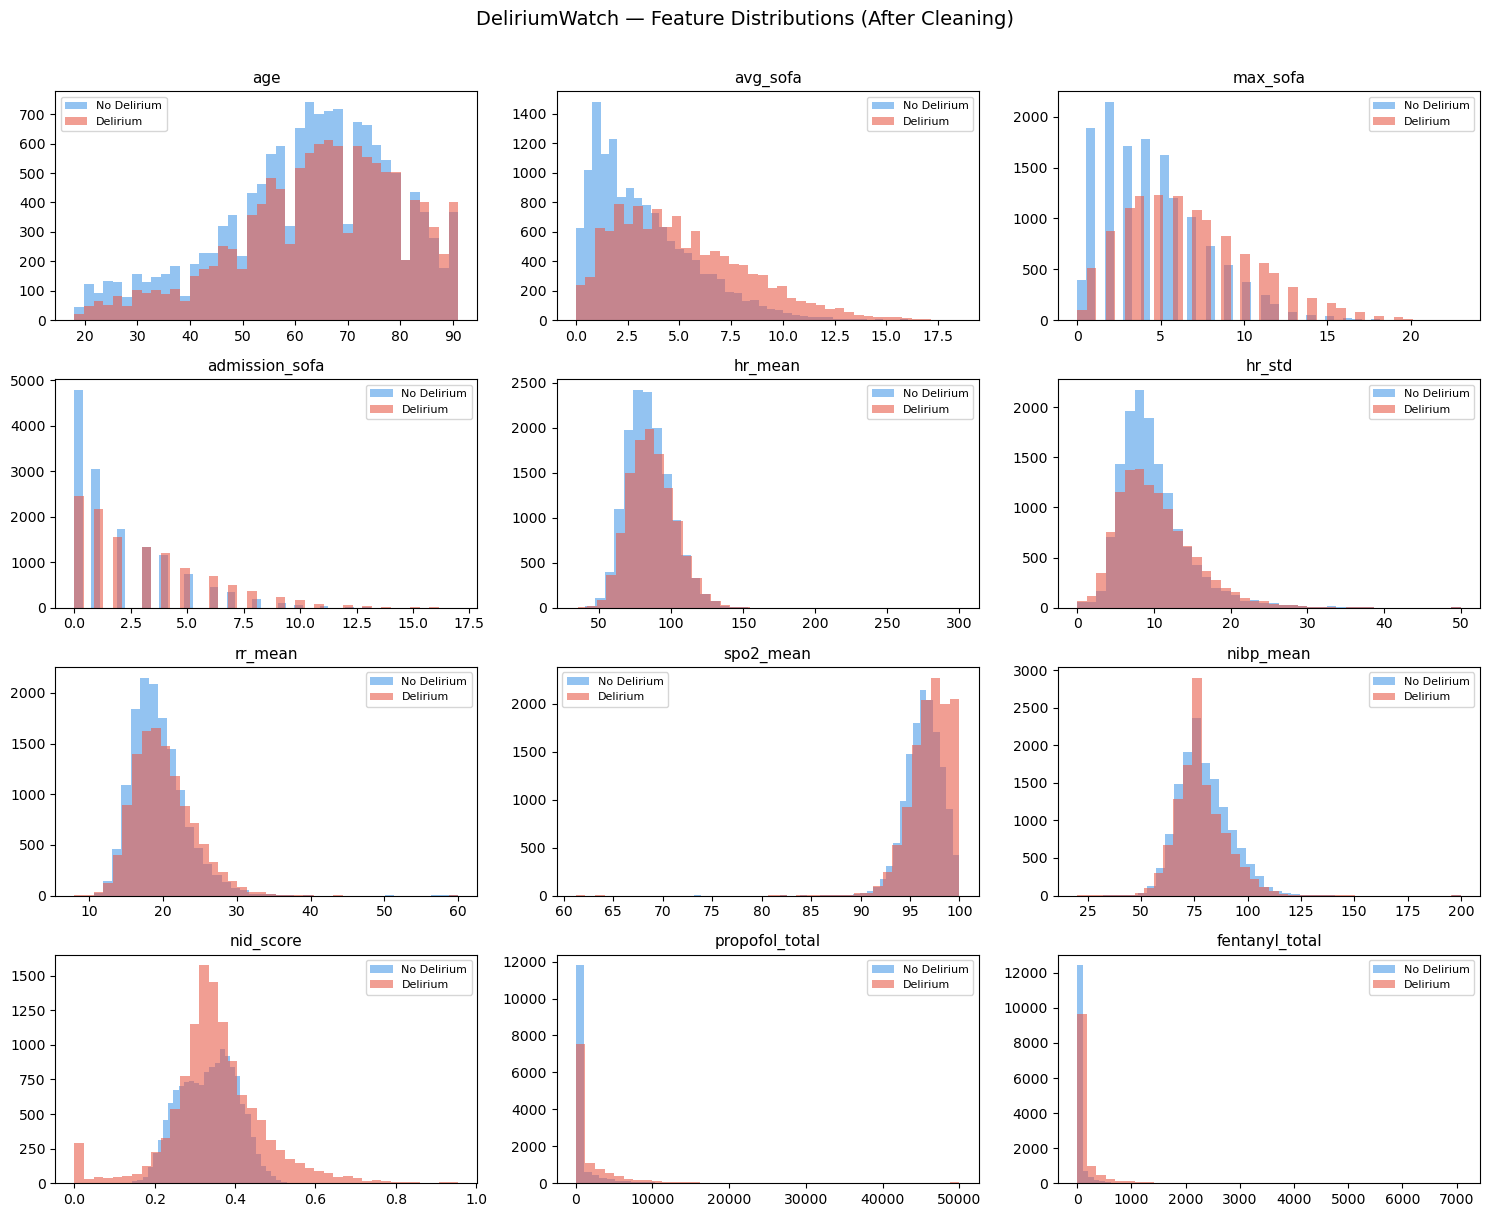

In [10]:
# Re-run distributions with clean data
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(
        df_clean[df_clean['delirium_label']==0][col],
        bins=40, alpha=0.6,
        color='#4C9BE8', label='No Delirium'
    )
    axes[i].hist(
        df_clean[df_clean['delirium_label']==1][col],
        bins=40, alpha=0.6,
        color='#E85D4C', label='Delirium'
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle(
    'DeliriumWatch — Feature Distributions (After Cleaning)',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

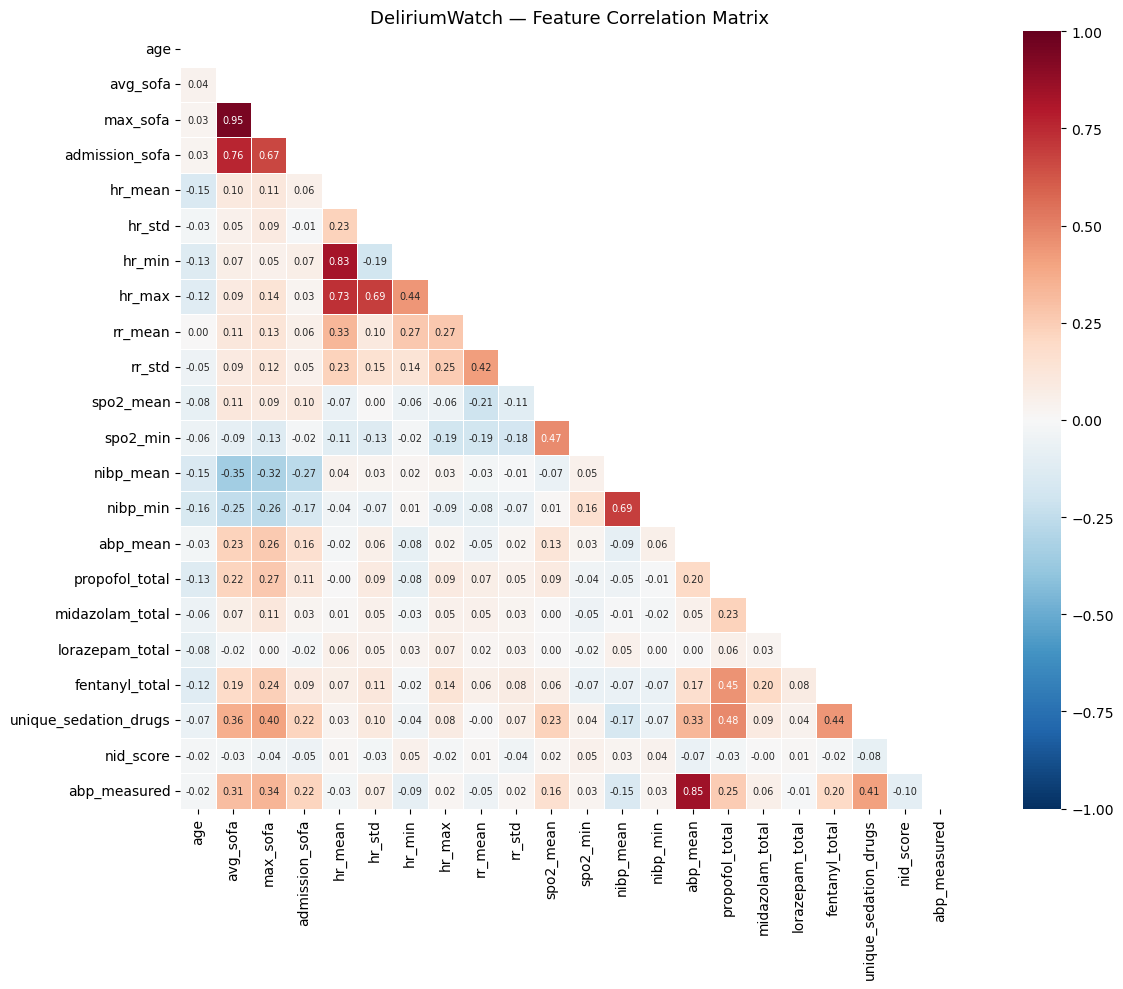

In [11]:
# Correlation heatmap
feature_cols = [col for col in df_clean.columns 
                if col not in ['delirium_label', 
                               'gender', 
                               'first_careunit']]

corr_matrix = df_clean[feature_cols].corr().round(2)

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7}
)

plt.title('DeliriumWatch — Feature Correlation Matrix', 
          fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
cols_to_drop_corr = ['max_sofa', 'hr_min','abp_mean','admission_sofa','hr_max','nibp_min',]
df_model = df_clean.drop(columns=cols_to_drop_corr)
print("Shape after correlation dropping:", df_model.shape)
print("Remaining features:", df_model.columns.tolist())

Shape after correlation dropping: (25843, 19)
Remaining features: ['delirium_label', 'age', 'gender', 'first_careunit', 'avg_sofa', 'hr_mean', 'hr_std', 'rr_mean', 'rr_std', 'spo2_mean', 'spo2_min', 'nibp_mean', 'propofol_total', 'midazolam_total', 'lorazepam_total', 'fentanyl_total', 'unique_sedation_drugs', 'nid_score', 'abp_measured']


In [13]:
print("Gender values:")
print(df_model['gender'].value_counts())
print("\nICU types:")
print(df_model['first_careunit'].value_counts())

Gender values:
gender
M    14646
F    11197
Name: count, dtype: int64

ICU types:
first_careunit
Medical Intensive Care Unit (MICU)                  4951
Cardiac Vascular Intensive Care Unit (CVICU)        4153
Medical/Surgical Intensive Care Unit (MICU/SICU)    3444
Surgical Intensive Care Unit (SICU)                 3321
Coronary Care Unit (CCU)                            3091
Neuro Intermediate                                  2837
Trauma SICU (TSICU)                                 2768
Neuro Surgical Intensive Care Unit (Neuro SICU)      549
Neuro Stepdown                                       541
Surgery/Vascular/Intermediate                        108
PACU                                                  44
Intensive Care Unit (ICU)                             13
Medicine                                              12
Surgery/Trauma                                        10
Neurology                                              1
Name: count, dtype: int64


In [14]:
#Encode categorical variables
df_encoded = df_model.copy()

# Gender only 2 values
df_encoded['gender'] = (
    df_encoded['gender']
    .map({'M': 0, 'F': 1})
)
print("Gender encoded: M=0, F=1")

# ICU type
icu_counts = df_encoded['first_careunit'].value_counts()
rare_icus = icu_counts[icu_counts < 100].index.tolist()
print(f"\nGrouping {len(rare_icus)} rare ICU types into 'Other':")
print(rare_icus)

df_encoded['first_careunit'] = (
    df_encoded['first_careunit']
    .apply(lambda x: 'Other' if x in rare_icus else x)
)

# One-hot encode ICU type
df_encoded = pd.get_dummies(
    df_encoded, 
    columns=['first_careunit'],
    prefix='icu',
    drop_first=True  
)

print(f"\nShape after encoding: {df_encoded.shape}")
print(f"New ICU columns: {[c for c in df_encoded.columns if c.startswith('icu')]}")

Gender encoded: M=0, F=1

Grouping 5 rare ICU types into 'Other':
['PACU', 'Intensive Care Unit (ICU)', 'Medicine', 'Surgery/Trauma', 'Neurology']

Shape after encoding: (25843, 28)
New ICU columns: ['icu_Coronary Care Unit (CCU)', 'icu_Medical Intensive Care Unit (MICU)', 'icu_Medical/Surgical Intensive Care Unit (MICU/SICU)', 'icu_Neuro Intermediate', 'icu_Neuro Stepdown', 'icu_Neuro Surgical Intensive Care Unit (Neuro SICU)', 'icu_Other', 'icu_Surgery/Vascular/Intermediate', 'icu_Surgical Intensive Care Unit (SICU)', 'icu_Trauma SICU (TSICU)']


In [15]:
df_encoded.to_csv('deliriumwatch_clean_V5.csv', index=False)
print("Saved deliriumwatch_clean_V5.csv")
print("Shape:", df_encoded.shape)

Saved deliriumwatch_clean_V5.csv
Shape: (25843, 28)
